In [2]:
import h5py
import matplotlib.pyplot as plt
import numpy as np 

# from multicam_tng.utils import c

from tqdm import tqdm

## Extract data

In [3]:
def convert_tng_mass2(gmass):
    """Convert TNG mass to log10(Msun)."""
    # TNG units are 1e10 Msun / h; https://www.tng-project.org/data/docs/specifications
    # return in units of log10(Msun)
    # robust to 0 mass
    return np.where(gmass > 0, np.log10(gmass * 1e10), 0)


In [4]:
# get gmass over all files 
subhalo_ids = []
subhalo_mass = []
stellar_mass = []
group_mass = [] 
hat_group_mass = [] 

count = 0
for ii in tqdm(range(0, 448)):
    filename = f'../../data/tng100-99/fof_subhalo_tab_099.{ii}.hdf5'
    with h5py.File(filename, 'r') as f:

        if 'GroupMass' in f['Group'].keys():
            for s in f['Group']['GroupMass']:
                group_mass.append(s)
            for s in f['Group']['Group_M_TopHat200']:
                hat_group_mass.append(s)
            

        if 'SubhaloMass' in f['Subhalo'].keys():
            for s in f['Subhalo']['SubhaloMass']:
                subhalo_ids.append(count)
                subhalo_mass.append(s)
                count+=1

            for s in f['Subhalo']['SubhaloMassInRadType'][:,4]: # 4 = star particles
                stellar_mass.append(s) 


subhalo_ids = np.array(subhalo_ids)
subhalo_mass = convert_tng_mass2(np.array(subhalo_mass)) # log10(Msun / h)
stellar_mass = convert_tng_mass2(np.array(stellar_mass)) # log10(Msun / h)
group_mass = convert_tng_mass2(np.array(group_mass))
hat_group_mass = convert_tng_mass2(np.array(hat_group_mass))

  0%|          | 0/448 [00:00<?, ?it/s]


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '../../data/tng100-99/fof_subhalo_tab_099.0.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
subhalo_ids.shape

(4371211,)

In [ ]:
mask = (stellar_mass > 8.75) & ( stellar_mass < 9.3)
sum(mask)

NameError: name 'stellar_mass' is not defined

In [6]:
stellar_mass.min()


np.float32(0.0)

In [7]:
subhalo_ids.shape, subhalo_mass.shape, stellar_mass.shape, 

((4371211,), (4371211,), (4371211,))

## Colors

In [8]:
file = "../../data/Subhalo_StellarPhot_p07c_cf00dust_res_conv_ns1_rad30pkpc_099.hdf5"

In [9]:
fc = h5py.File(file, 'r')

In [10]:
fc.keys()

<KeysViewHDF5 ['Subhalo_StellarPhot_p07c_cf00dust_res_conv_ns1_rad30pkpc', 'subhaloIDs']>

In [11]:
fc['subhaloIDs'][:]

array([      0,       1,       2, ..., 4371208, 4371209, 4371210],
      shape=(4371211,), dtype=int32)

In [12]:
sdss_g = fc['Subhalo_StellarPhot_p07c_cf00dust_res_conv_ns1_rad30pkpc'][:, 1, 0]
sdss_i = fc['Subhalo_StellarPhot_p07c_cf00dust_res_conv_ns1_rad30pkpc'][:, 3, 0]
gi = sdss_g - sdss_i
gi.shape

(4371211,)

In [13]:
np.sum(np.isnan(gi)) / len(gi)

np.float64(0.9229625382988833)

In [14]:
fc['subhaloIDs'][:].shape

(4371211,)

## L* sample

(array([1.26000e+02, 1.58000e+02, 2.11000e+02, 2.57000e+02, 3.83000e+02,
        7.13000e+02, 3.80283e+05, 9.36891e+05, 8.07047e+05, 6.25606e+05,
        4.37003e+05, 3.27299e+05, 2.38317e+05, 1.72375e+05, 1.23843e+05,
        8.93160e+04, 6.33620e+04, 4.67340e+04, 3.37640e+04, 2.37400e+04,
        1.70270e+04, 1.24610e+04, 9.31600e+03, 6.93700e+03, 5.17200e+03,
        3.65000e+03, 2.60500e+03, 1.94500e+03, 1.41200e+03, 9.85000e+02,
        7.40000e+02]),
 array([ 7.        ,  7.16129017,  7.32258081,  7.48387098,  7.64516115,
         7.8064518 ,  7.96774197,  8.12903214,  8.2903223 ,  8.45161247,
         8.61290359,  8.77419376,  8.93548393,  9.0967741 ,  9.25806427,
         9.41935444,  9.58064556,  9.74193573,  9.9032259 , 10.06451607,
        10.22580624, 10.38709641, 10.54838753, 10.7096777 , 10.87096786,
        11.03225803, 11.1935482 , 11.35483837, 11.51612949, 11.67741966,
        11.83870983, 12.        ]),
 [<matplotlib.patches.Polygon at 0x117b26850>])

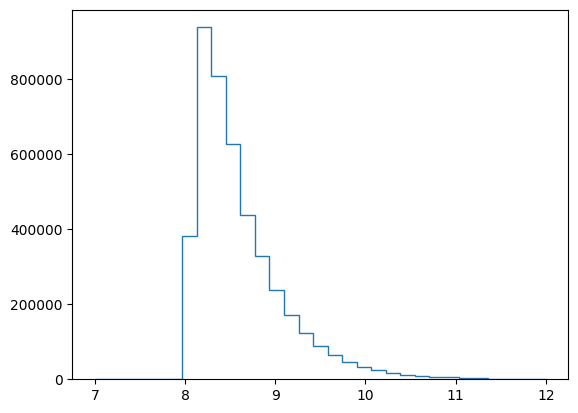

In [18]:
plt.hist(subhalo_mass, bins=31, histtype='step', range=(7, 12))
# plt.yscale('log')÷

In [19]:
sum((subhalo_mass < 12.2) & (subhalo_mass > 11.8))

np.int64(1512)

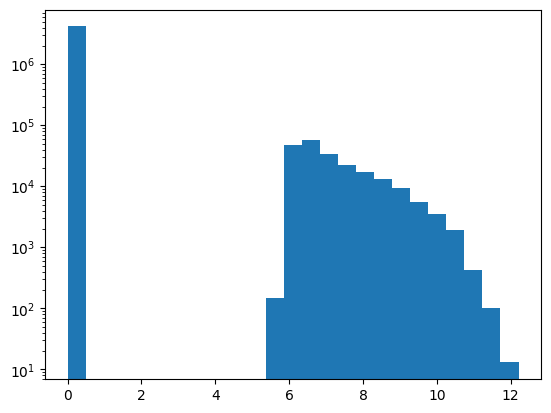

In [20]:
plt.hist(stellar_mass, bins=25)
plt.yscale('log')

In [25]:
mask = (stellar_mass > 8.75) & ( stellar_mass < 9.3)
_gi = gi[mask]
_gi.shape

(10681,)

In [26]:
np.sum(np.isnan(_gi)) / len(_gi)

np.float64(0.0)

(array([  1.,   1.,   3.,  12.,  31.,  68., 107., 191., 348., 548., 736.,
        818., 911., 873., 837., 638., 537., 407., 311., 231., 223., 211.,
        200., 309., 589., 576., 355., 311., 215.,  64.,  19.]),
 array([0.13386917, 0.17196901, 0.21006885, 0.24816871, 0.28626853,
        0.32436839, 0.36246824, 0.40056807, 0.43866792, 0.47676778,
        0.5148676 , 0.55296743, 0.59106731, 0.62916714, 0.66726696,
        0.70536685, 0.74346668, 0.7815665 , 0.81966639, 0.85776621,
        0.89586604, 0.93396592, 0.97206575, 1.01016557, 1.04826546,
        1.08636522, 1.12446511, 1.16256499, 1.20066476, 1.23876464,
        1.27686453, 1.31496429]),
 <BarContainer object of 31 artists>)

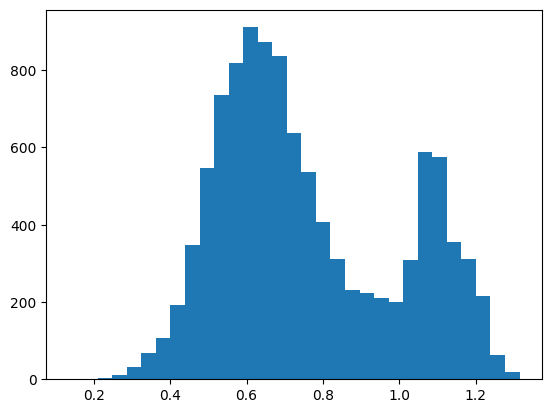

In [27]:
plt.hist(_gi, bins=31)

## Playground

In [19]:
file = f'../../data/tng/100/fof_subhalo_tab_099.99.hdf5'

In [20]:
f = h5py.File(file, 'r')

In [21]:
f.keys()

<KeysViewHDF5 ['Config', 'Group', 'Header', 'IDs', 'Parameters', 'Subhalo']>

In [9]:
sorted(f['Subhalo'].keys())

['SubhaloBHMass',
 'SubhaloBHMdot',
 'SubhaloBfldDisk',
 'SubhaloBfldHalo',
 'SubhaloCM',
 'SubhaloFlag',
 'SubhaloGasMetalFractions',
 'SubhaloGasMetalFractionsHalfRad',
 'SubhaloGasMetalFractionsMaxRad',
 'SubhaloGasMetalFractionsSfr',
 'SubhaloGasMetalFractionsSfrWeighted',
 'SubhaloGasMetallicity',
 'SubhaloGasMetallicityHalfRad',
 'SubhaloGasMetallicityMaxRad',
 'SubhaloGasMetallicitySfr',
 'SubhaloGasMetallicitySfrWeighted',
 'SubhaloGrNr',
 'SubhaloHalfmassRad',
 'SubhaloHalfmassRadType',
 'SubhaloIDMostbound',
 'SubhaloLen',
 'SubhaloLenType',
 'SubhaloMass',
 'SubhaloMassInHalfRad',
 'SubhaloMassInHalfRadType',
 'SubhaloMassInMaxRad',
 'SubhaloMassInMaxRadType',
 'SubhaloMassInRad',
 'SubhaloMassInRadType',
 'SubhaloMassType',
 'SubhaloParent',
 'SubhaloPos',
 'SubhaloSFR',
 'SubhaloSFRinHalfRad',
 'SubhaloSFRinMaxRad',
 'SubhaloSFRinRad',
 'SubhaloSpin',
 'SubhaloStarMetalFractions',
 'SubhaloStarMetalFractionsHalfRad',
 'SubhaloStarMetalFractionsMaxRad',
 'SubhaloStarMetalli

In [23]:
f['Subhalo']['SubhaloMass'].shape, f['Subhalo']['SubhaloMassInRadType'].shape # 4th elements corresponds to star particles

((2478,), (2478, 6))

In [106]:
from multicam.tng.utils import convert_tng_mass

gmass = convert_tng_mass(f['Group']['Group_M_TopHat200'][:])